In [123]:
import numpy as np
import pandas as pd
 
# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
 
# Prétraitement
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
 
# Prétraitement
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
 
# Modèles de Machine Learning
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
 
# Évaluation des modèles
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    r2_score
)

### 1- Echantillon de 10 lignes

In [124]:
df = pd.read_csv('titanic.csv')
pd.set_option('display.expand_frame_repr', False)
    
print(df.head(10))

   PassengerId  Survived  Pclass                                          Name     Sex   Age  SibSp  Parch     Ticket     Fare Cabin Embarked
0          892         0       3                              Kelly, Mr. James    male  34.5      0      0     330911   7.8292   NaN        Q
1          893         1       3              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0     363272   7.0000   NaN        S
2          894         0       2                     Myles, Mr. Thomas Francis    male  62.0      0      0     240276   9.6875   NaN        Q
3          895         0       3                              Wirz, Mr. Albert    male  27.0      0      0     315154   8.6625   NaN        S
4          896         1       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1    3101298  12.2875   NaN        S
5          897         0       3                    Svensson, Mr. Johan Cervin    male  14.0      0      0       7538   9.2250   NaN        S
6     

### 2- Comprendre la structure des données

- PassengerID : Identifiant unique pour chaque passager **(Int)**
- Survived : Indique si le passager a survécu (1) ou non (0) **(Bool)**
- Pclass : Classe du billet (1 = Première classe, 2 = Deuxième classe, 3 = Troisième classe) **(Int)**
- Name : Nom du passager **(String)**
- Sex : Sexe du passager **(String)**
- Age : Âge du passager **(Int)**
- SibSp : Nombre de frères et sœurs / conjoints à bord **(Int)**
- Parch : Nombre de parents / enfants à bord **(Int)**
- Ticket : Numéro de billet **(Int)**
- Fare : Tarif du billet **(Float)**
- Cabin : Numéro de cabine **(String)**
- Embarked : Port d'embarquement (C = Cherbourg, Q = Queenstown, S = Southampton) **(Char)**

### 3- Analyse statistique

In [125]:
print("\n=== Taux de survie global ===")
print(f"Taux de survie: {df['Survived'].mean():.2%}")

print("\n=== Survie par sexe ===")
print(df.groupby(['Sex', 'Survived']).size().unstack(fill_value=0))

print("\n=== Survie par classe ===")
print(df.groupby('Pclass')['Survived'].agg(['mean', 'count']))

print("\n=== Statistiques d'âge par survie ===")
print(df.groupby('Survived')['Age'].agg(['mean', 'min', 'max', 'median']))

print("\n=== Répartition des ports d'embarquement ===")
print(df['Embarked'].value_counts())

print("\n=== Statistiques des tarifs ===")
print(f"Tarif minimum: {df['Fare'].min():.2f}")
print(f"Tarif maximum: {df['Fare'].max():.2f}")
print(f"Tarif moyen: {df['Fare'].mean():.2f}")
print(f"Tarif médian: {df['Fare'].median():.2f}")


=== Taux de survie global ===
Taux de survie: 36.36%

=== Survie par sexe ===
Survived    0    1
Sex               
female      0  152
male      266    0

=== Survie par classe ===
            mean  count
Pclass                 
1       0.467290    107
2       0.322581     93
3       0.330275    218

=== Statistiques d'âge par survie ===
               mean   min   max  median
Survived                               
0         30.272732  0.33  67.0    27.0
1         30.272362  0.17  76.0    27.0

=== Répartition des ports d'embarquement ===
Embarked
S    270
C    102
Q     46
Name: count, dtype: int64

=== Statistiques des tarifs ===
Tarif minimum: 0.00
Tarif maximum: 512.33
Tarif moyen: 35.63
Tarif médian: 14.45


### 4- Cleaning

In [126]:
# Détecter les valeurs manquantes
print("=== Valeurs manquantes ===")
print(df.isnull().sum())
print(f"\nNombre total de valeurs manquantes: {df.isnull().sum().sum()}")

# Détecter les lignes en double
print("\n=== Lignes en double ===")
duplicates = df.duplicated().sum()
print(f"Nombre de lignes en double: {duplicates}")

=== Valeurs manquantes ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Nombre total de valeurs manquantes: 414

=== Lignes en double ===
Nombre de lignes en double: 0


0 lignes en double -> pas besoin de supression

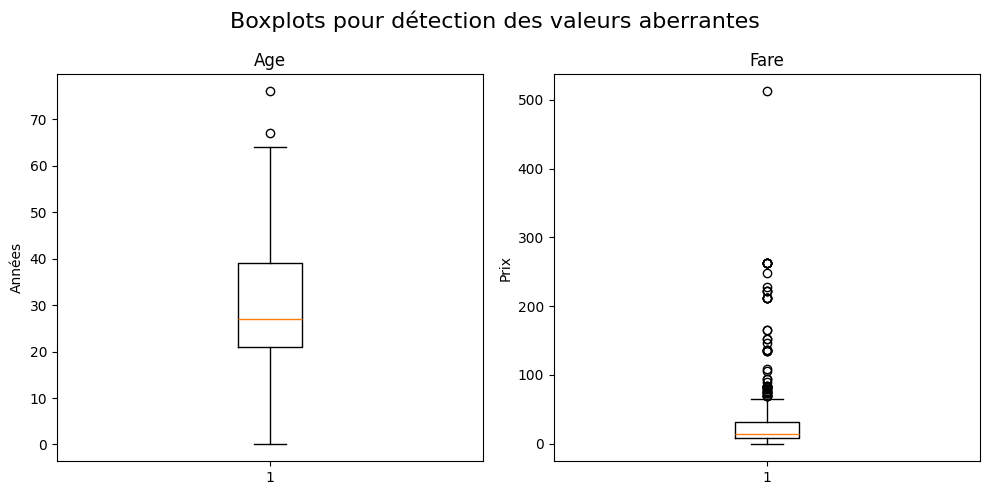


=== Avant suppression des valeurs aberrantes ===
Nombre de lignes: 418

=== Après suppression des valeurs aberrantes ===
Nombre de lignes: 273
Lignes supprimées: 145


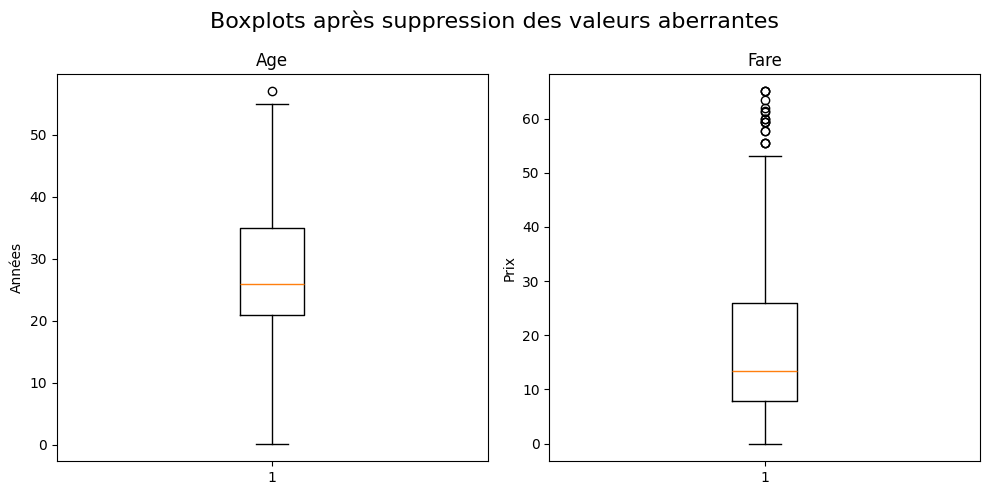

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Boxplots pour détection des valeurs aberrantes', fontsize=16)

# Boxplot pour Age
axes[0].boxplot(df['Age'].dropna(), vert=True)
axes[0].set_title('Age')
axes[0].set_ylabel('Années')

# Boxplot pour Fare
axes[1].boxplot(df['Fare'].dropna(), vert=True)
axes[1].set_title('Fare')
axes[1].set_ylabel('Prix')

plt.tight_layout()
plt.show()

# Supprimer les valeurs aberrantes en utilisant la méthode IQR
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

print(f"\n=== Avant suppression des valeurs aberrantes ===")
print(f"Nombre de lignes: {len(df)}")

df = remove_outliers(df, 'Fare')
df = remove_outliers(df, 'Age')

print(f"\n=== Après suppression des valeurs aberrantes ===")
print(f"Nombre de lignes: {len(df)}")
print(f"Lignes supprimées: {418 - len(df)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Boxplots après suppression des valeurs aberrantes', fontsize=16)

# Boxplot pour Age
axes[0].boxplot(df['Age'].dropna(), vert=True)
axes[0].set_title('Age')
axes[0].set_ylabel('Années')

# Boxplot pour Fare
axes[1].boxplot(df['Fare'].dropna(), vert=True)
axes[1].set_title('Fare')
axes[1].set_ylabel('Prix')


plt.tight_layout()
plt.show()

In [128]:
# Convertir les colonnes au bon type de données
df['PassengerId'] = df['PassengerId'].astype(int)
df['Survived'] = df['Survived'].astype(bool)
df['Pclass'] = df['Pclass'].astype(int)
df['Name'] = df['Name'].astype(str)
df['Sex'] = df['Sex'].astype(str)
df['Age'] = df['Age'].fillna(df['Age'].median()).astype(int) # Car il y a des valeurs manquantes pour Age
df['SibSp'] = df['SibSp'].astype(int)
df['Parch'] = df['Parch'].astype(int)
df['Ticket'] = df['Ticket'].astype(str)
df['Fare'] = df['Fare'].astype(float)
df['Cabin'] = df['Cabin'].astype(str)
df['Embarked'] = df['Embarked'].astype(str)

print("=== Types de données après conversion ===")
print(df.dtypes)
print("\n=== Aperçu des données ===")
print(df.head())

=== Types de données après conversion ===
PassengerId      int64
Survived          bool
Pclass           int64
Name            object
Sex             object
Age              int64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

=== Aperçu des données ===
   PassengerId  Survived  Pclass                                          Name     Sex  Age  SibSp  Parch   Ticket     Fare Cabin Embarked
0          892     False       3                              Kelly, Mr. James    male   34      0      0   330911   7.8292   nan        Q
1          893      True       3              Wilkes, Mrs. James (Ellen Needs)  female   47      1      0   363272   7.0000   nan        S
3          895     False       3                              Wirz, Mr. Albert    male   27      0      0   315154   8.6625   nan        S
4          896      True       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  fema

### 5- Visualisation

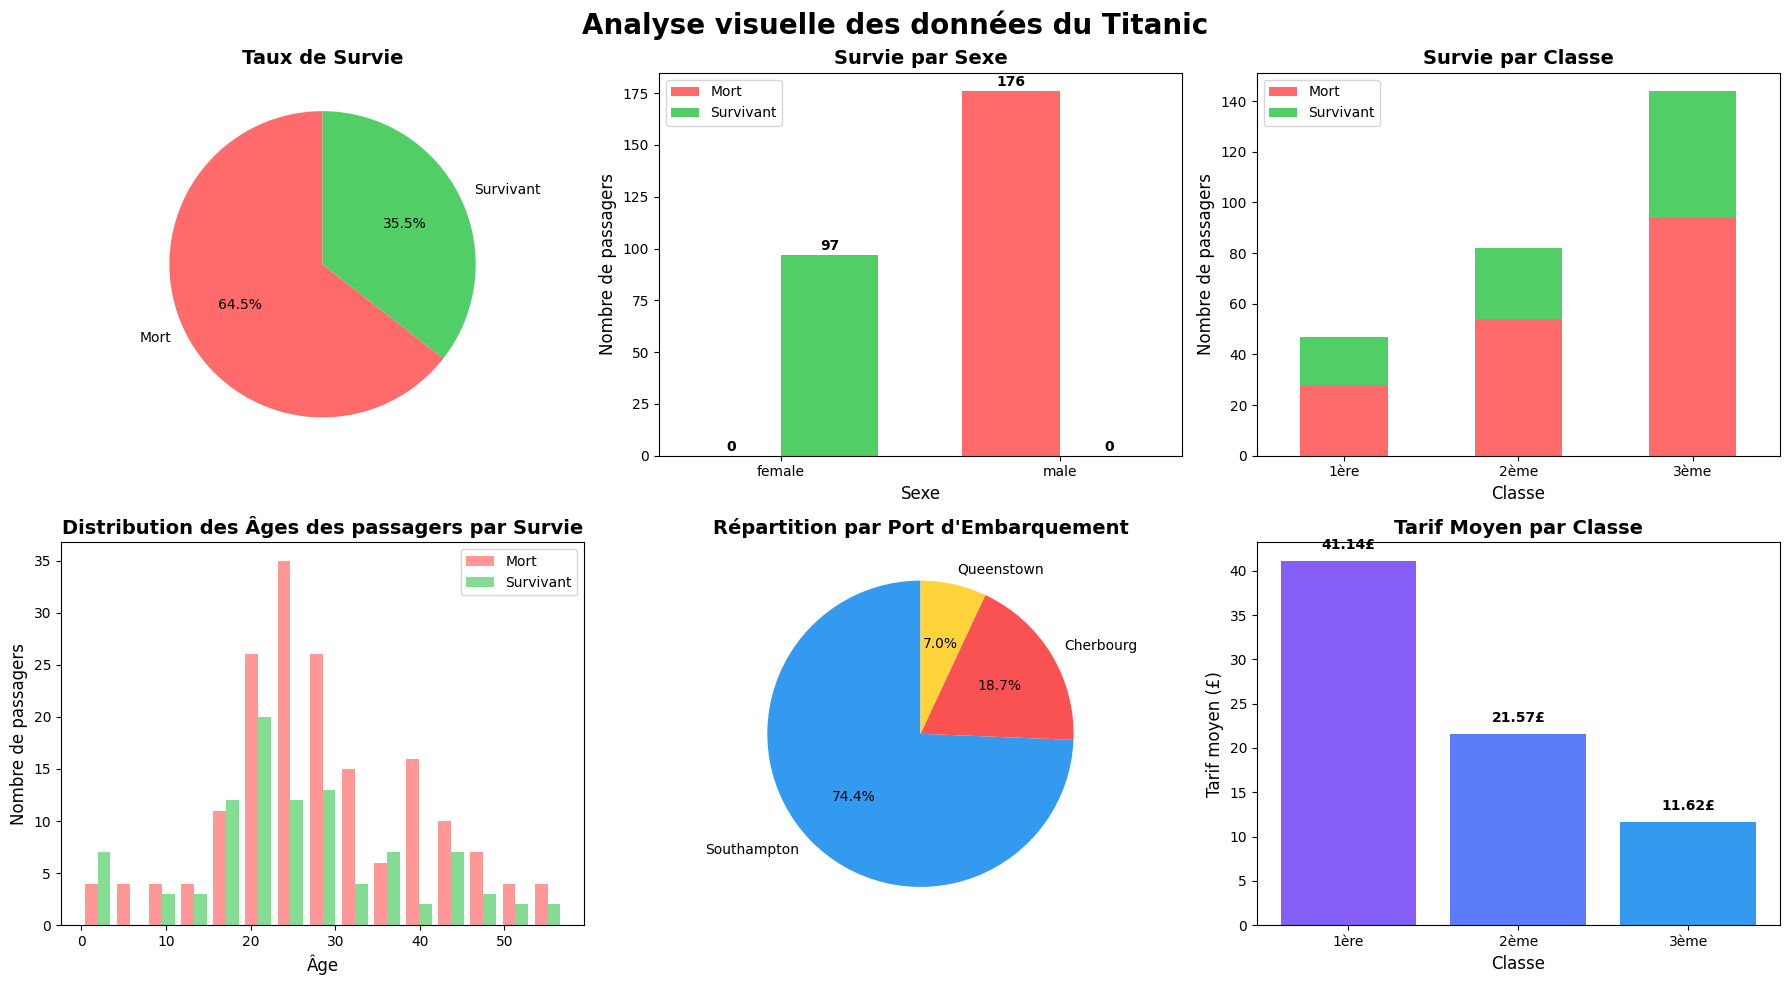

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Analyse visuelle des données du Titanic', fontsize=20, fontweight='bold')

# 1. Taux de survie
survival_counts = df['Survived'].value_counts()
axes[0, 0].pie(survival_counts, labels=['Mort', 'Survivant'], autopct='%1.1f%%', 
               colors=['#ff6b6b', '#51cf66'], startangle=90)
axes[0, 0].set_title('Taux de Survie', fontsize=14, fontweight='bold')

# 2. Survie par sexe
survival_by_sex = df.groupby(['Sex', 'Survived']).size().unstack(fill_value=0)
x_pos = np.arange(len(survival_by_sex.index))
width = 0.35
axes[0, 1].bar(x_pos - width/2, survival_by_sex[False], width, label='Mort', color='#ff6b6b')
axes[0, 1].bar(x_pos + width/2, survival_by_sex[True], width, label='Survivant', color='#51cf66')
axes[0, 1].set_xlabel('Sexe', fontsize=12)
axes[0, 1].set_ylabel('Nombre de passagers', fontsize=12)
axes[0, 1].set_title('Survie par Sexe', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(survival_by_sex.index)
axes[0, 1].legend()

for i, v in enumerate(survival_by_sex[False]):
    axes[0, 1].text(i - width/2, v + 1, str(v), ha='center', va='bottom', fontweight='bold')
for i, v in enumerate(survival_by_sex[True]):
    axes[0, 1].text(i + width/2, v + 1, str(v), ha='center', va='bottom', fontweight='bold')

# 3. Survie par classe
survival_by_class = df.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)
survival_by_class.plot(kind='bar', stacked=True, ax=axes[0, 2], 
                       color=['#ff6b6b', '#51cf66'], rot=0)
axes[0, 2].set_xlabel('Classe', fontsize=12)
axes[0, 2].set_ylabel('Nombre de passagers', fontsize=12)
axes[0, 2].set_title('Survie par Classe', fontsize=14, fontweight='bold')
axes[0, 2].legend(['Mort', 'Survivant'])
axes[0, 2].set_xticklabels(['1ère', '2ème', '3ème'])

# 4. Distribution des âges par survie
ages_survived = df[df['Survived'] == True]['Age']
ages_died = df[df['Survived'] == False]['Age']
axes[1, 0].hist([ages_died, ages_survived], bins=15, label=['Mort', 'Survivant'], 
                color=['#ff6b6b', '#51cf66'], alpha=0.7)
axes[1, 0].set_xlabel('Âge', fontsize=12)
axes[1, 0].set_ylabel('Nombre de passagers', fontsize=12)
axes[1, 0].set_title('Distribution des Âges des passagers par Survie', fontsize=14, fontweight='bold')
axes[1, 0].legend()

# 5. Répartition des ports d'embarquement
embarked_counts = df['Embarked'].value_counts()
axes[1, 1].pie(embarked_counts, labels=['Southampton', 'Cherbourg', 'Queenstown'], 
               autopct='%1.1f%%', colors=['#339af0', '#fa5252', '#ffd43b'], startangle=90)
axes[1, 1].set_title('Répartition par Port d\'Embarquement', fontsize=14, fontweight='bold')

# 6. Tarif moyen par classe
fare_by_class = df.groupby('Pclass')['Fare'].mean()
axes[1, 2].bar(fare_by_class.index, fare_by_class.values, color=['#845ef7', '#5c7cfa', '#339af0'])
axes[1, 2].set_xlabel('Classe', fontsize=12)
axes[1, 2].set_ylabel('Tarif moyen (£)', fontsize=12)
axes[1, 2].set_title('Tarif Moyen par Classe', fontsize=14, fontweight='bold')
axes[1, 2].set_xticks([1, 2, 3])
axes[1, 2].set_xticklabels(['1ère', '2ème', '3ème'])

for i, v in enumerate(fare_by_class.values):
    axes[1, 2].text(i + 1, v + 1, f'{v:.2f}£', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()